In [171]:
import numpy as np
import seaborn as sns
import random
import pandas as pd
import matplotlib.pyplot as plt
import math
from copy import deepcopy

In [172]:
# metod generise rcbd tabelu tako sto je popuni sa nasumicnim brojevima iz [lower, upper] --> ovo je okej jer mi radimo sa vestackim podacima
# generalno gledano to nisu nasumicne vrednosti vec izmerene vrednosti u eksperimentu
def generate_rcbd_table(n_rows = 2, n_cols = 2, lower_bound = 1, upper_bound = 30, seed=None):
    if seed is not None:
        np.random.seed(seed)

    data = np.random.randint(lower_bound, upper_bound + 1, size=(n_rows, n_cols))
    df = pd.DataFrame(data,
                      index=[f"T{i+1}" for i in range(n_rows)],
                      columns=[f"B{j+1}" for j in range(n_cols)])
    return df

In [194]:
def calculate_sse(predicted, true = None, mask=None):
    predicted = predicted.astype(float)
    # check if its corrent for else case
    if true is not None and mask is not None:
      true = true.astype(float)
      error = (predicted - true) ** 2
      #print("Error matrix:\n", error)
      masked_error = error * mask
      #print("Masked error matrix:\n", masked_error)
      sse = np.sum(masked_error)
    else:
      # in this case, data isnt artifically generated so we actually dont know the missing value at all and only have predicted matrix
      # model based SSE

      sample_mean = predicted.mean()
      row_means = predicted.mean(axis=1)
      col_means = predicted.mean(axis=0)

      sse = 0
      for i in range(predicted.shape[0]):
          for j in range(predicted.shape[1]):
              y_ij = predicted[i, j]
              y_hat_ij = row_means[i] + col_means[j] - sample_mean
              sse += (y_ij - y_hat_ij) ** 2
    return sse

<h4>Test primeri i vizualizacija razlike<h4>

In [195]:
# originalna RCBD tabela (npr. 3 tretmana x 3 bloka)
true_table = generate_rcbd_table(3, 3, 1, 20, 42)
display(true_table)
# maska:
mask = pd.DataFrame(0, index=true_table.index, columns=true_table.columns)
# izaberemo proizvoljna polja za promenu
mask.iloc[0, 1] = 1
mask.iloc[2, 2] = 1

# predlozene vrednosti koje bi GA dao kao rešenja
predicted_table = true_table.copy().astype(float)
predicted_table.iloc[0, 1] = 19.5
predicted_table.iloc[2, 2] = 12.5
sse = calculate_sse(predicted_table.values, true_table.values, mask.values)
print(f"SSE: {sse:.4f}")

,B1,B2,B3
T1,7,20,15
T2,11,8,7
T3,19,11,11


SSE: 2.5000


In [196]:
error_table = (predicted_table - true_table)
masked_error_table = error_table * mask

print("Razlika (samo na pozicijama sa greškom):")
display(masked_error_table)

Razlika (samo na pozicijama sa greškom):


,B1,B2,B3
T1,0.0,-0.5,0.0
T2,0.0,0.0,0.0
T3,0.0,0.0,1.5


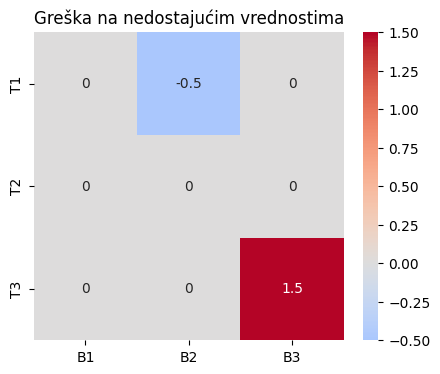

In [197]:
plt.figure(figsize=(5,4))
sns.heatmap(masked_error_table, annot=True, cmap="coolwarm", center=0)
plt.title("Greška na nedostajućim vrednostima")
plt.show()

In [198]:
#nasumicno uklanjanje jedne vrednosti iz rcbd tabele
def hide_random_value(table: pd.DataFrame, seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    table_hidden = table.copy() #kopija tabele sa jednom vrednošću zamenjenom sa np.nan

    rows, cols = table.shape
    i = random.randint(0, rows - 1)
    j = random.randint(0, cols - 1)
    #(i,j) je pozicija gde je vrednost uklonjena

    true_value = table_hidden.iat[i, j] #originalna vrednost na (i,j) poziciji
    table_hidden.iat[i, j] = np.nan

    return table_hidden, (i, j), true_value

In [226]:
#proba funkcije za uklanjanje jedne vrednosti
df = generate_rcbd_table(5, 5, 10, 30, 42)
print("Originalna tabela:")
display(df)

df_hidden, pos, original_val = hide_random_value(df, 41)

print("\nTabela sa skrivenom vrednošću:")
display(df_hidden)

print(f"\nUklonjena vrednost: {original_val} na poziciji {pos}")

Originalna tabela:


,B1,B2,B3,B4,B5
T1,16,29,24,20,17
T2,30,16,28,20,20
T3,30,13,17,12,30
T4,11,21,15,11,30
T5,10,21,21,26,19



Tabela sa skrivenom vrednošću:


,B1,B2,B3,B4,B5
T1,16,29,24.0,20,17
T2,30,16,28.0,20,20
T3,30,13,17.0,12,30
T4,11,21,NaN,11,30
T5,10,21,21.0,26,19



Uklonjena vrednost: 15 na poziciji (3, 2)


In [227]:
class Individual:
    def __init__(self, rcbd : pd.DataFrame, rcbd_true : pd.DataFrame = None):
        self.code = calculate_code(rcbd)
        self.rcbd = rcbd # table with missing value
        self.rcbd_true = rcbd_true # optional, we dont have this with real data
        self.fitness = self.calc_fitness()

    def calc_fitness(self):
        # if chromosome code isnt in allowed range, fitness is set to -inf
        rcbd_c = self.rcbd.copy()
        decode_value, row, col = self.decode()

        t_values = rcbd_c.iloc[row].dropna().values
        min_value = min(t_values)
        max_value = max(t_values)

        if decode_value > max_value or decode_value < min_value:
          return -float('inf')

        rcbd_c.iloc[row, col] = decode_value
        if self.rcbd_true is not None:
          mask = pd.DataFrame(0, index=self.rcbd.index, columns=self.rcbd.columns)
          mask.iloc[row, col] = 1
          return -calculate_sse(rcbd_c.values, self.rcbd_true.values, mask.values)
        else:
          return -calculate_sse(rcbd_c.values)

    def binary_code(self):
      return ''.join(['1' if bit else '0' for bit in self.code])

    def decode(self):
      # (min (row where nan is) + int(self.code)) / 10
      t_row_ids, t_col_ids = np.where(self.rcbd.isna())
      t_row_id = t_row_ids[0]
      t_col_id = t_col_ids[0]

      t_values = self.rcbd.iloc[t_row_id].dropna().values
      min_value = min(t_values)

      decoded_value = (min_value + int(self.binary_code(), 2))
      return decoded_value, t_row_id, t_col_id

    def __str__(self):
        binary = self.binary_code()
        decoded_value, row, col = self.decode()
        return f"Chromosome binary code is {binary} and decoded value is {decoded_value} (at row {row}, column {col})\n"


In [228]:
# this function returns code for given individual (chromosome). Each individual should represent the missing value in the RCBD table.
def calculate_code(table : pd.DataFrame):
  # first we need to determine range for missing value.
  t_row_ids, _ = np.where(table.isna()) # treatment where the missing value occurs
  t_row_id = t_row_ids[0]

  # remove from the t_row_id the nan value
  t_values = table.iloc[t_row_id].dropna().values
  # scale all values as int
  #t_rounded_values = [round(v, 1) for v in t_values]
  #t_scaled_values = [int(round(v * 10)) for v in t_rounded_values]

  min_value = min(t_values)
  max_value = max(t_values)
  n = max_value - min_value + 1  # number of values in [min, max]
  size = math.ceil(math.log2(n)) # size of the chromosome
  chromosome = [random.random() < 0.2 for _ in range(size)]

  return chromosome

In [229]:
chromosome = Individual(df_hidden, df)

In [230]:
print(type(chromosome))

<class '__main__.Individual'>


In [231]:
print("Random generated chromosome: ", chromosome.binary_code())

Random generated chromosome:  01000


In [232]:
decoded_val, row, col = chromosome.decode()
print(f"Decoded value: {decoded_val} and row: {row}, col: {col} where missing value was.")

Decoded value: 19.0 and row: 3, col: 2 where missing value was.


In [233]:
print("Fitness of this random generated chromosome is: ", chromosome.fitness)

Fitness of this random generated chromosome is:  -16.0


In [234]:
def initial_population(rcbd : pd.DataFrame, rcbd_true: pd.DataFrame = None, size = 10):
    population = []
    while True:
        if rcbd_true is not None:
          chromosome = Individual(rcbd, rcbd_true)
        else:
          chromosome = Individual(rcbd, rcbd_true) # TO DO: fix fitness in this case
        decode_value, row, _ = chromosome.decode()

        # condition: decoded chromosome in range [min_value, max_value]
        t_values = rcbd.iloc[row].dropna().values
        min_value = min(t_values)
        max_value = max(t_values)

        if decode_value <= max_value and decode_value >= min_value:
            population.append(chromosome)

        if len(population) == size:
            break

    return population

In [235]:
population = initial_population(df_hidden, df)

In [236]:
for individual in population:
    print(individual)

Chromosome binary code is 00000 and decoded value is 11.0 (at row 3, column 2)

Chromosome binary code is 00011 and decoded value is 14.0 (at row 3, column 2)

Chromosome binary code is 01001 and decoded value is 20.0 (at row 3, column 2)

Chromosome binary code is 01000 and decoded value is 19.0 (at row 3, column 2)

Chromosome binary code is 00101 and decoded value is 16.0 (at row 3, column 2)

Chromosome binary code is 00010 and decoded value is 13.0 (at row 3, column 2)

Chromosome binary code is 00100 and decoded value is 15.0 (at row 3, column 2)

Chromosome binary code is 01000 and decoded value is 19.0 (at row 3, column 2)

Chromosome binary code is 00110 and decoded value is 17.0 (at row 3, column 2)

Chromosome binary code is 00000 and decoded value is 11.0 (at row 3, column 2)



In [237]:
#Selecting individuals from the population based on roulette selection
def roulette_selection(population, num_selected=2, epsilon=1e-6):
    assert num_selected <= len(population), "Cannot select more individuals than population size without replacement."
    # check if its correct
    # assert not any(np.array_equal(candidate.code, other.code) for other in selected) == False, "Cannot select more individuals than population size without replacement."
    population = [ind for ind in population if not np.isinf(ind.fitness)]
    fitness_values = np.array([ind.fitness for ind in population])

    min_fit = np.min(fitness_values)
    shifted_fitness = fitness_values - min_fit + epsilon

    total = np.sum(shifted_fitness)
    probabilities = shifted_fitness / total

    selected = []
    while True:
        idx = np.random.choice(len(population), p=probabilities)
        candidate = population[idx]
        if not any(np.array_equal(candidate.code, other.code) for other in selected):
          selected.append(candidate)
        if len(selected) == num_selected:
          break;

    return selected

In [238]:
# two-point crossover between parents if number of bits in code is bigger, else one-point
# 10 001 1
# 11 111 0
# 10 111 1
# 11 001 0
def crossover(parent1: Individual, parent2: Individual, child1: Individual, child2: Individual):
    # randomly select two breakpoints
    bp1 = random.randrange(1, len(parent1.code)) # first and last position are excluded because we want to take the middle part of the parent
    # with few bits, crossover often swaps only one identical bit, producing identical offsprings to parents.

    if len(parent1.code) < 5:
        child1.code[:bp1] = parent1.code[:bp1]
        child1.code[bp1:] = parent2.code[bp1:]

        child2.code[:bp1] = parent2.code[:bp1]
        child2.code[bp1:] = parent1.code[bp1:]
    bp2 = bp1
    while bp2 == bp1:
        bp2 = random.randrange(1, len(parent1.code))

    bps = sorted([bp1, bp2])

    child1.code[:bps[0]] = parent1.code[:bps[0]]
    child1.code[bps[0]:bps[1]] = parent2.code[bps[0]:bps[1]]
    child1.code[bps[1]:] = parent1.code[bps[1]:]

    child2.code[:bps[0]] = parent2.code[:bps[0]]
    child2.code[bps[0]:bps[1]] = parent1.code[bps[0]:bps[1]]
    child2.code[bps[1]:] = parent2.code[bps[1]:]

In [239]:
def mutation(child: Individual, mutation_prob = 0.2):
  # mutation is performed such as following : randomly select two breaking points and invert all the bits between them
  bp1 = random.randrange(1, len(child.code))
  bp2 = bp1
  while bp2 == bp1:
      bp2 = random.randrange(1, len(child.code))

  bps = sorted([bp1, bp2])
  if random.random() < mutation_prob:
    for i in range(bps[0], bps[1]):
      child.code[i] = not child.code[i]

In [240]:
def ga(initial_population, num_generations, elitism_size, mutation_prob):

    new_population = [Individual(initial_population[0].rcbd, initial_population[0].rcbd_true) for _ in range(len(initial_population))]

    # if elitism_size % 2 != population_size % 2:
    #     elitism_size += 1

    # best_fitnesses = []
    population = deepcopy(initial_population)
    for it in range(num_generations):
        population.sort(key=lambda x: x.fitness, reverse = True)
        # best_fitnesses.append(population[0].fitness)
        new_population[:elitism_size] = population[:elitism_size]
        for i in range(elitism_size, len(population), 2):
            parents = roulette_selection(population)
            crossover(parents[0], parents[1], new_population[i], new_population[i+1])

            mutation(new_population[i], mutation_prob)
            mutation(new_population[i+1], mutation_prob)

            # we set fitness only when creating an instance, meaning that after crossover and mutation fitness wont be updated.
            new_population[i].fitness = new_population[i].calc_fitness()
            new_population[i+1].fitness = new_population[i+1].calc_fitness()

        population = deepcopy(new_population)

    return population

In [241]:
population = ga(population, 20, 2, 0.2)

In [242]:
best_predicted_nan_value = max(population, key = lambda x: x.fitness)
best_predicted_nan_value_decoded, row, col = best_predicted_nan_value.decode()
true_value = df.iloc[row, col]
print(f'True value that was hidden in the RCBD table: {true_value}')
print(f'Predicted value for null in RCBD table with GA is: {best_predicted_nan_value_decoded}')

True value that was hidden in the RCBD table: 15
Predicted value for null in RCBD table with GA is: 15.0
